<a href="https://colab.research.google.com/github/dharshinikumaravel2004-byte/ecg-classification-resnet/blob/main/Class_Balanced_Loss_Loss_(RESNET).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, BatchNormalization, GlobalAveragePooling1D, Add, Input, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

TRAIN_PATH = "/content/drive/MyDrive/mit dataset/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/mit dataset/mitbih_test.csv"  # FIXED

train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Mounted at /content/drive
Train shape: (87554, 188)
Test shape: (21892, 188)


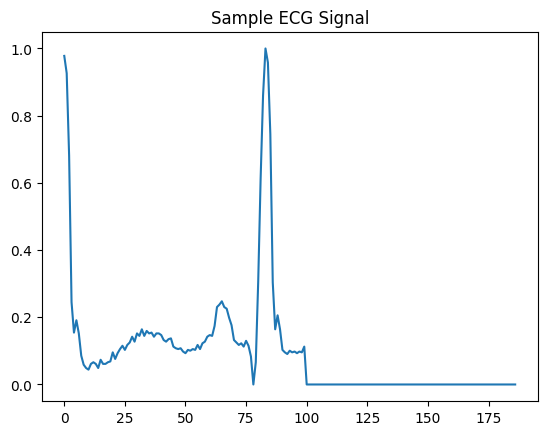

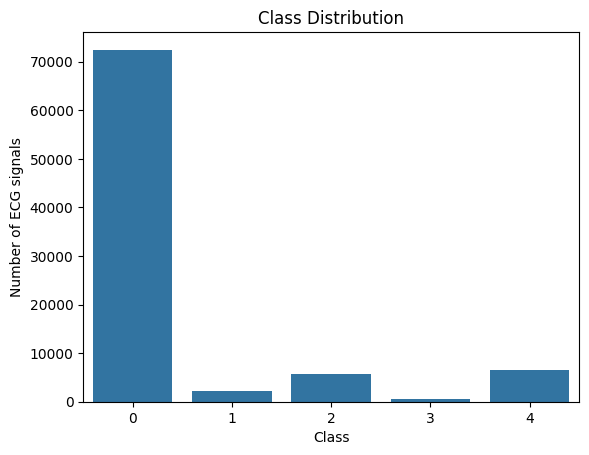

0
0


In [ ]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0,1,2,3,4]

sns.barplot(x=classes, y=counts.values)
plt.xlabel("Class")
plt.ylabel("Number of ECG signals")
plt.title("Class Distribution")
plt.show()

print(train.isna().sum().sum())
print(test.isna().sum().sum())

In [ ]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

In [ ]:
import numpy as np

samples_per_class = np.bincount(y_train.astype(int))

beta = 0.9999

effective_num = 1.0 - np.power(beta, samples_per_class)

class_weights = (1.0 - beta) / effective_num

class_weights = class_weights / np.sum(class_weights) * len(samples_per_class)

print(class_weights)

[0.18876864 0.94632351 0.42925506 3.0379894  0.39766339]


In [ ]:
import tensorflow as tf

cb_weights = tf.constant(class_weights, dtype=tf.float32)

def class_balanced_loss(y_true, y_pred):

    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)

    ce = -y_true * tf.math.log(y_pred)

    weighted_ce = ce * cb_weights

    loss = tf.reduce_sum(weighted_ce, axis=1)

    return loss

In [ ]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE:
187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_res),
    y=y_res
)

class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0)}


In [ ]:
X_res = np.array(X_res).reshape(-1, 187, 1)
X_test = np.array(X_test).reshape(-1, 187, 1)

In [ ]:
# Convert to one-hot
y_res_cat = to_categorical(y_res, 5)
y_test_cat = to_categorical(y_test, 5)



In [ ]:
def resnet_block(x, filters, stride=1):

    shortcut = x

    x = Conv1D(filters, 3, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv1D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)

    return x

In [ ]:
def resnet_ecg():

    inputs = Input(shape=(187,1))

    x = Conv1D(32, 3, activation='relu')(inputs)
    x = BatchNormalization()(x)

    x = resnet_block(x, 64)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x, 128)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x, 256)

    x = GlobalAveragePooling1D()(x)

    x = Dense(128, activation='relu')(x)

    outputs = Dense(5, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)

    model.compile(
    optimizer='adam',
    loss=class_balanced_loss,
    metrics=['accuracy']
)
    return model

In [ ]:
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_res, y_res_cat, test_size=0.2, random_state=42
)

In [ ]:
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_res, y_res)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_res[train_idx], X_res[val_idx]
    y_tr, y_va = y_res_cat[train_idx], y_res_cat[val_idx]

    model = resnet_ecg()

    model.fit(
        X_tr,
        y_tr,
        epochs=10,
        batch_size=64,
        verbose=1
    )

    loss, acc = model.evaluate(X_va, y_va, verbose=0)

    print(f"Fold {fold+1} Accuracy: {acc:.4f}")

    cv_accuracies.append(acc)

print("\nMean CV Accuracy:", np.mean(cv_accuracies))


Fold 1
Epoch 1/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 57s 10ms/step - accuracy: 0.9048 - loss: 0.1115
Epoch 2/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - accuracy: 0.9594 - loss: 0.0430
Epoch 3/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9726 - loss: 0.0285
Epoch 4/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9802 - loss: 0.0206
Epoch 5/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9851 - loss: 0.0156
Epoch 6/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9873 - loss: 0.0136
Epoch 7/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.9901 - loss: 0.0104
Epoch 8/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9919 - loss: 0.0086
Epoch 9/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9919 - loss: 0.0091
Epoch 10/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9931 - loss: 0.0072
Fold 1 Accuracy: 0.9067

Fold 2
Epoch 1/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 51s 11ms/step - accuracy: 

In [ ]:
model = resnet_ecg()

history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val_final, y_val_final),
    epochs=10,
    batch_size=64
)

Epoch 1/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 66s 12ms/step - accuracy: 0.9094 - loss: 0.1052 - val_accuracy: 0.5978 - val_loss: 6.3458
Epoch 2/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 45s 10ms/step - accuracy: 0.9647 - loss: 0.0374 - val_accuracy: 0.9226 - val_loss: 0.0597
Epoch 3/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 44s 10ms/step - accuracy: 0.9771 - loss: 0.0240 - val_accuracy: 0.9802 - val_loss: 0.0253
Epoch 4/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 46s 10ms/step - accuracy: 0.9833 - loss: 0.0174 - val_accuracy: 0.8965 - val_loss: 0.3750
Epoch 5/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 45s 10ms/step - accuracy: 0.9865 - loss: 0.0142 - val_accuracy: 0.7594 - val_loss: 1.8753
Epoch 6/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 45s 10ms/step - accuracy: 0.9896 - loss: 0.0108 - val_accuracy: 0.9605 - val_loss: 0.1023
Epoch 7/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 46s 10ms/step - accuracy: 0.9916 - loss: 0.0090 - val_accuracy: 0.9275 - val_loss: 0.4172
Epoch 8/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 46s 10ms/step - accuracy: 0.9928 -

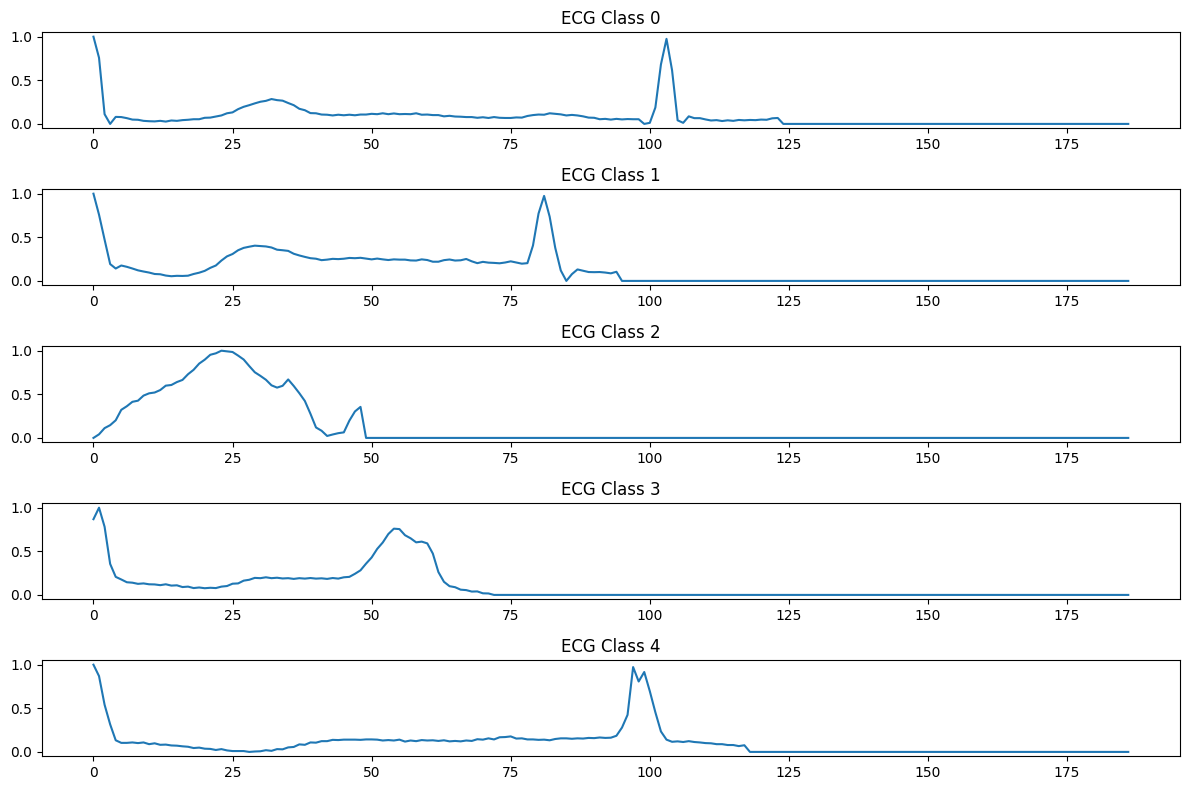

In [ ]:
plt.figure(figsize=(12,8))

for cls in range(5):
    idx = np.where(y_test == cls)[0][0]

    plt.subplot(5,1,cls+1)
    plt.plot(X_test[idx].reshape(187))
    plt.title(f"ECG Class {cls}")
    plt.tight_layout()

plt.show()

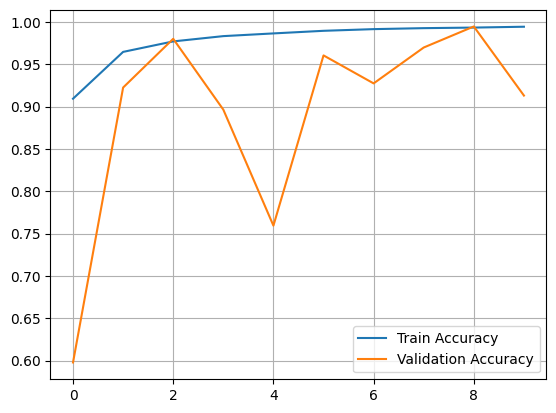

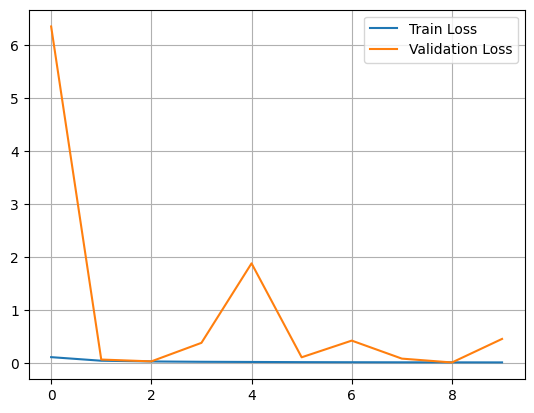

In [ ]:
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [ ]:
y_val_pred_prob = model.predict(X_va)
y_val_pred = np.argmax(y_val_pred_prob, axis=1)

y_val_true = np.argmax(y_va, axis=1)

mcc_val = matthews_corrcoef(y_val_true, y_val_pred)
print("Validation MCC:", mcc_val)

3775/3775 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step
Validation MCC: 0.8978118290029311


In [ ]:
y_pred = np.argmax(model.predict(X_test), axis=1)
print(np.unique(y_pred))

685/685 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
[0 1 2 3 4]


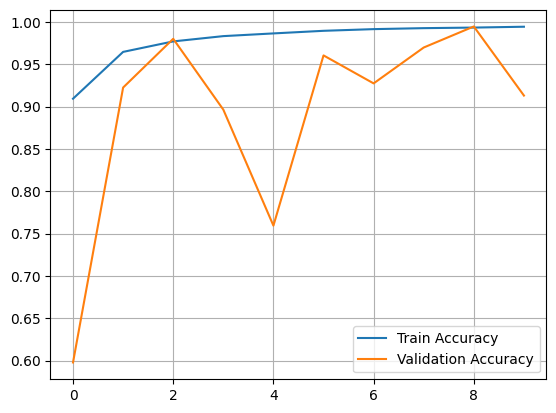

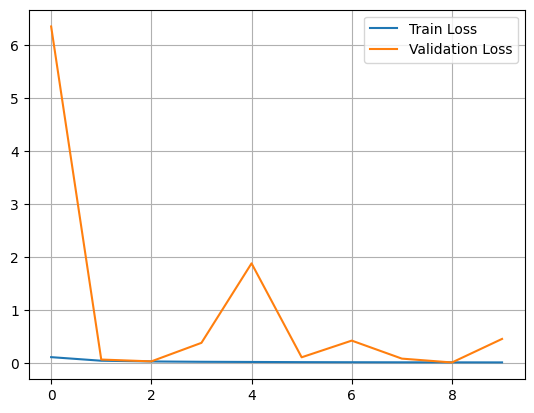

In [ ]:
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

y_test_pred = np.argmax(model.predict(X_test), axis=1)
y_test_true = np.argmax((y_test_cat + 1)//2, axis=1)

print(classification_report(y_test_true, y_test_pred))

Test Accuracy: 0.9733
685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     18118
           1       0.93      0.47      0.63       556
           2       0.96      0.93      0.94      1448
           3       0.94      0.63      0.76       162
           4       1.00      0.95      0.97      1608

    accuracy                           0.97     21892
   macro avg       0.96      0.79      0.86     21892
weighted avg       0.97      0.97      0.97     21892



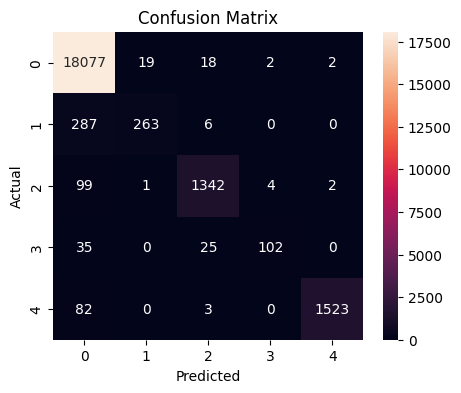

In [ ]:
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()